<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab


In [2]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

In [4]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

## Exploratory Data Analysis


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [5]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = await fetch(URL)
dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.


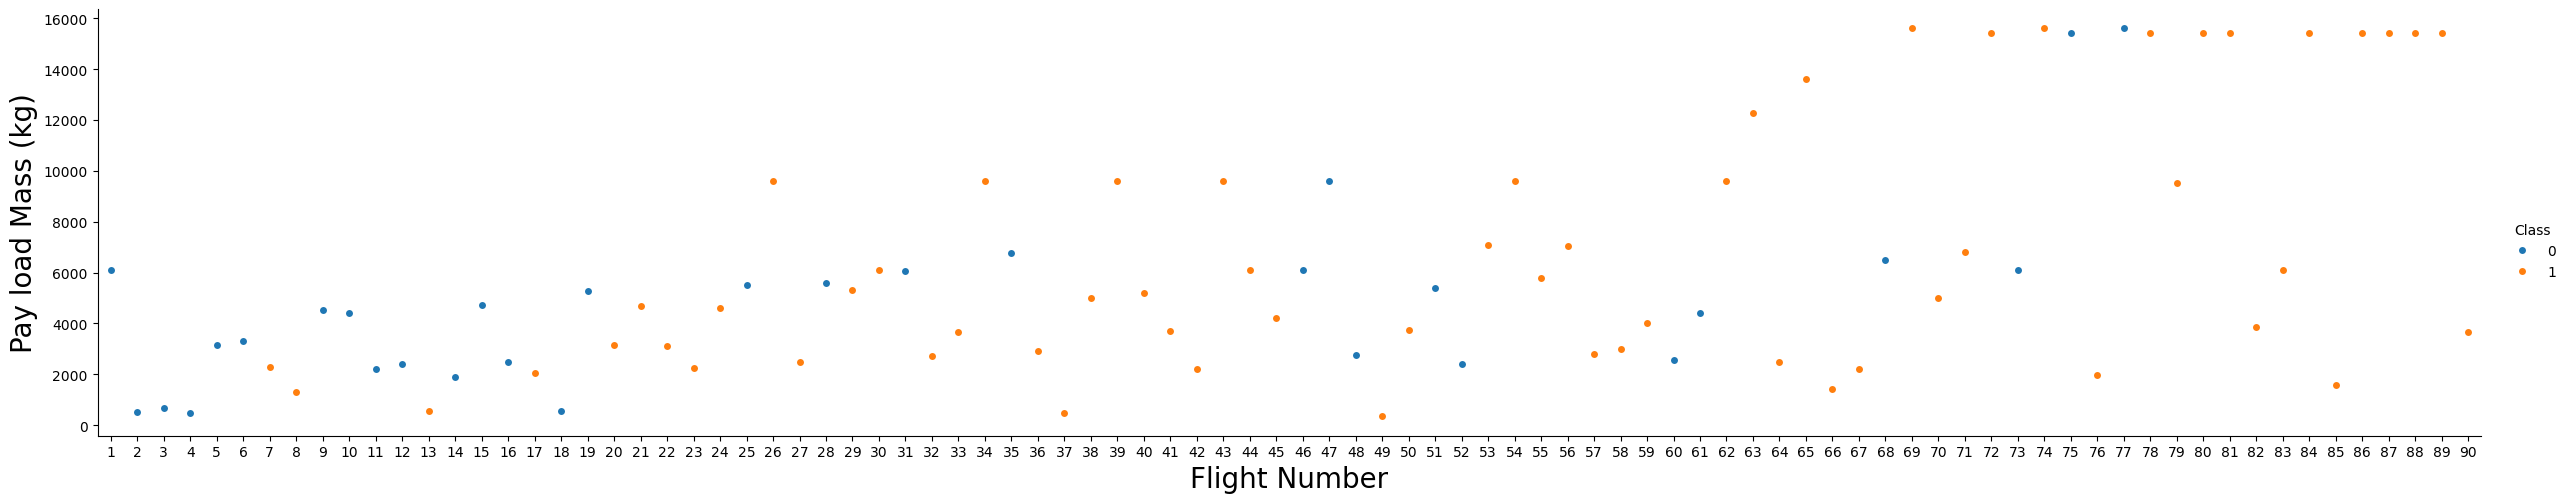

In [6]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


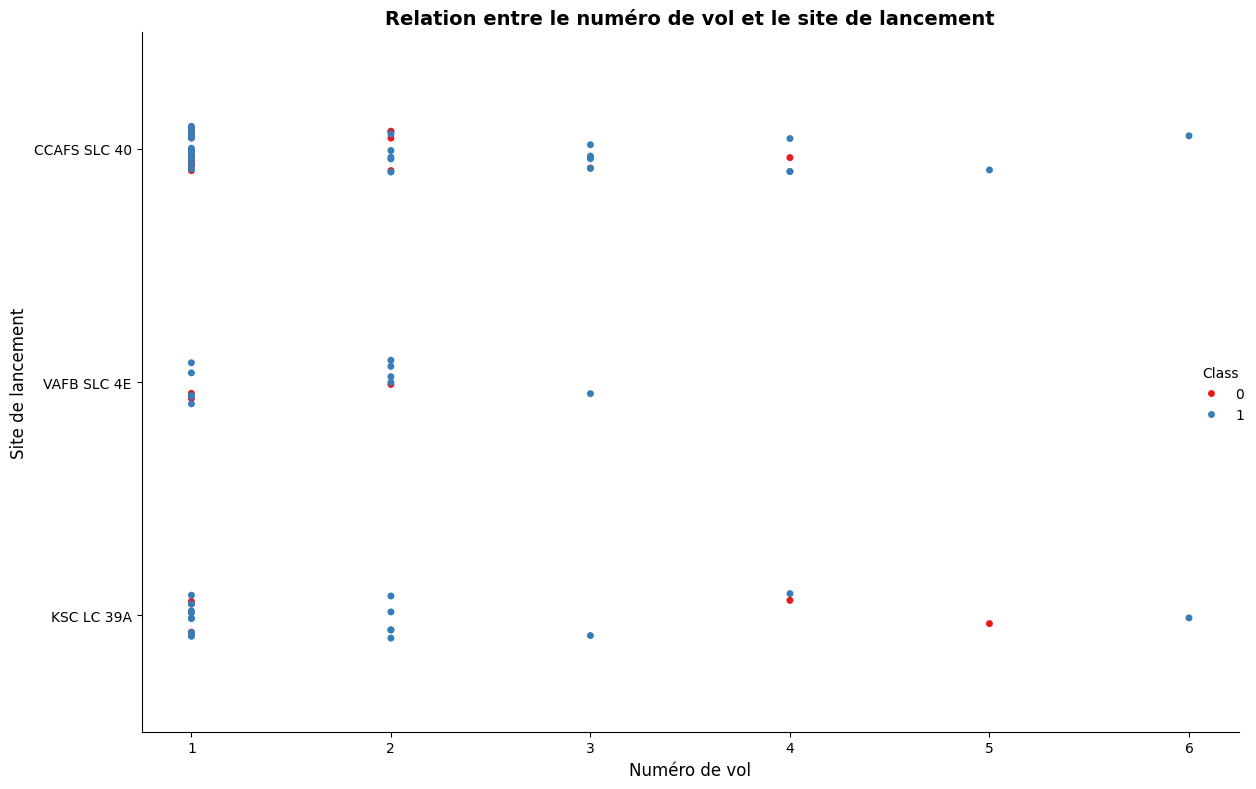

In [7]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value

import seaborn as sns
import matplotlib.pyplot as plt

# Trouver les colonnes
flight_col = None
site_col = None
class_col = None

for col in df.columns:
    if 'flight' in col.lower() or 'number' in col.lower():
        flight_col = col
    if 'site' in col.lower() or 'launch' in col.lower():
        if col != flight_col:
            site_col = col
    if 'class' in col.lower() or 'landing_class' in col.lower():
        class_col = col

if flight_col and site_col and class_col:
    # Créer le catplot
    sns.catplot(
        x=flight_col,
        y=site_col,
        hue=class_col,
        data=df,
        height=8,
        aspect=1.5,
        palette='Set1'
    )
    
    plt.title('Relation entre le numéro de vol et le site de lancement', fontsize=14, weight='bold')
    plt.xlabel('Numéro de vol', fontsize=12)
    plt.ylabel('Site de lancement', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("❌ Colonnes nécessaires non trouvées")
    print("Colonnes disponibles:", df.columns.tolist())

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload Mass and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


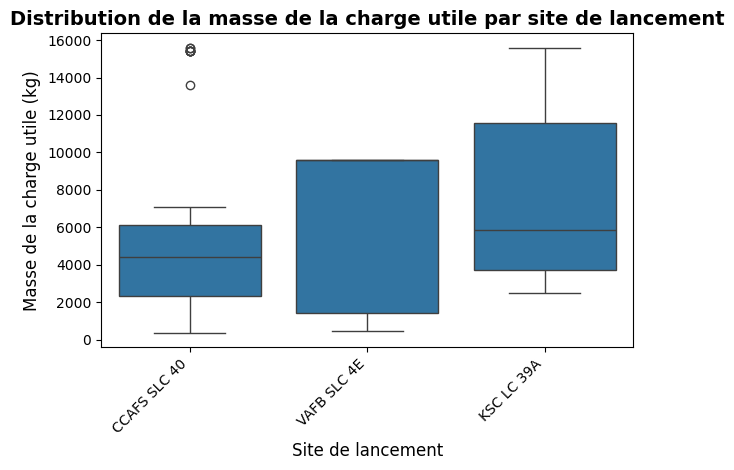

In [9]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value

import seaborn as sns
import matplotlib.pyplot as plt

# Version sans palette pour éviter l'avertissement
sns.boxplot(
    x='LaunchSite',
    y='PayloadMass',
    data=df
)

plt.title('Distribution de la masse de la charge utile par site de lancement', fontsize=14, weight='bold')
plt.xlabel('Site de lancement', fontsize=12)
plt.ylabel('Masse de la charge utile (kg)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


=== STATISTIQUES PAR ORBITE ===
       success_rate  count
Orbit                     
ES-L1         100.0      1
GEO           100.0      1
HEO           100.0      1
SSO           100.0      5
VLEO           86.0     14
LEO            71.0      7
MEO            67.0      3
PO             67.0      9
ISS            62.0     21
GTO            52.0     27
SO              0.0      1


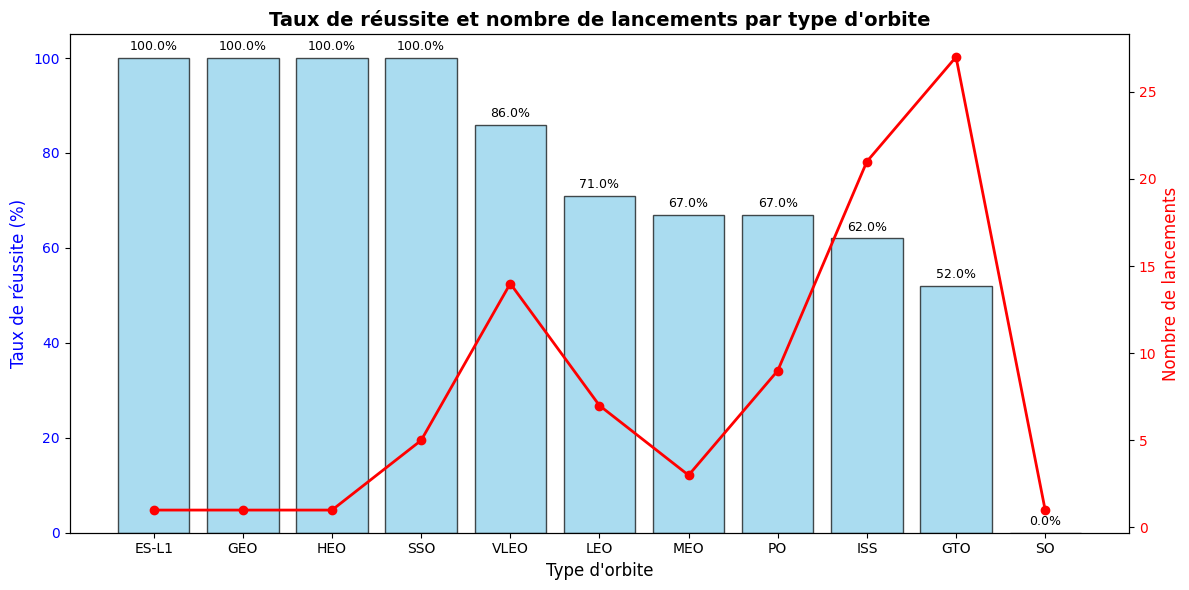

In [10]:
# HINT use groupby method on Orbit column and get the mean of Class column

# Trouver les colonnes
orbit_col = None
landing_class_col = None

for col in df.columns:
    if 'orbit' in col.lower():
        orbit_col = col
    if 'class' in col.lower():
        landing_class_col = col

if orbit_col and landing_class_col:
    # Calculer le taux de réussite et le nombre de lancements
    orbit_stats = df.groupby(orbit_col).agg({
        landing_class_col: ['mean', 'count']
    }).round(2)
    orbit_stats.columns = ['success_rate', 'count']
    orbit_stats['success_rate'] = orbit_stats['success_rate'] * 100
    orbit_stats = orbit_stats.sort_values('success_rate', ascending=False)
    
    print("=== STATISTIQUES PAR ORBITE ===")
    print(orbit_stats)
    
    # Créer un graphique avec deux axes
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Barres pour le taux de réussite
    bars = ax1.bar(orbit_stats.index, orbit_stats['success_rate'], 
                   color='skyblue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Type d\'orbite', fontsize=12)
    ax1.set_ylabel('Taux de réussite (%)', fontsize=12, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_ylim(0, 105)
    
    # Ajouter les valeurs sur les barres
    for bar, rate in zip(bars, orbit_stats['success_rate']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Axe secondaire pour le nombre de lancements
    ax2 = ax1.twinx()
    ax2.plot(orbit_stats.index, orbit_stats['count'], 'o-', color='red', linewidth=2)
    ax2.set_ylabel('Nombre de lancements', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title('Taux de réussite et nombre de lancements par type d\'orbite', fontsize=14, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("❌ Colonnes nécessaires non trouvées")

Analyze the plotted bar chart to identify which orbits have the highest success rates.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


✅ Colonne 'landing_class' créée avec succès


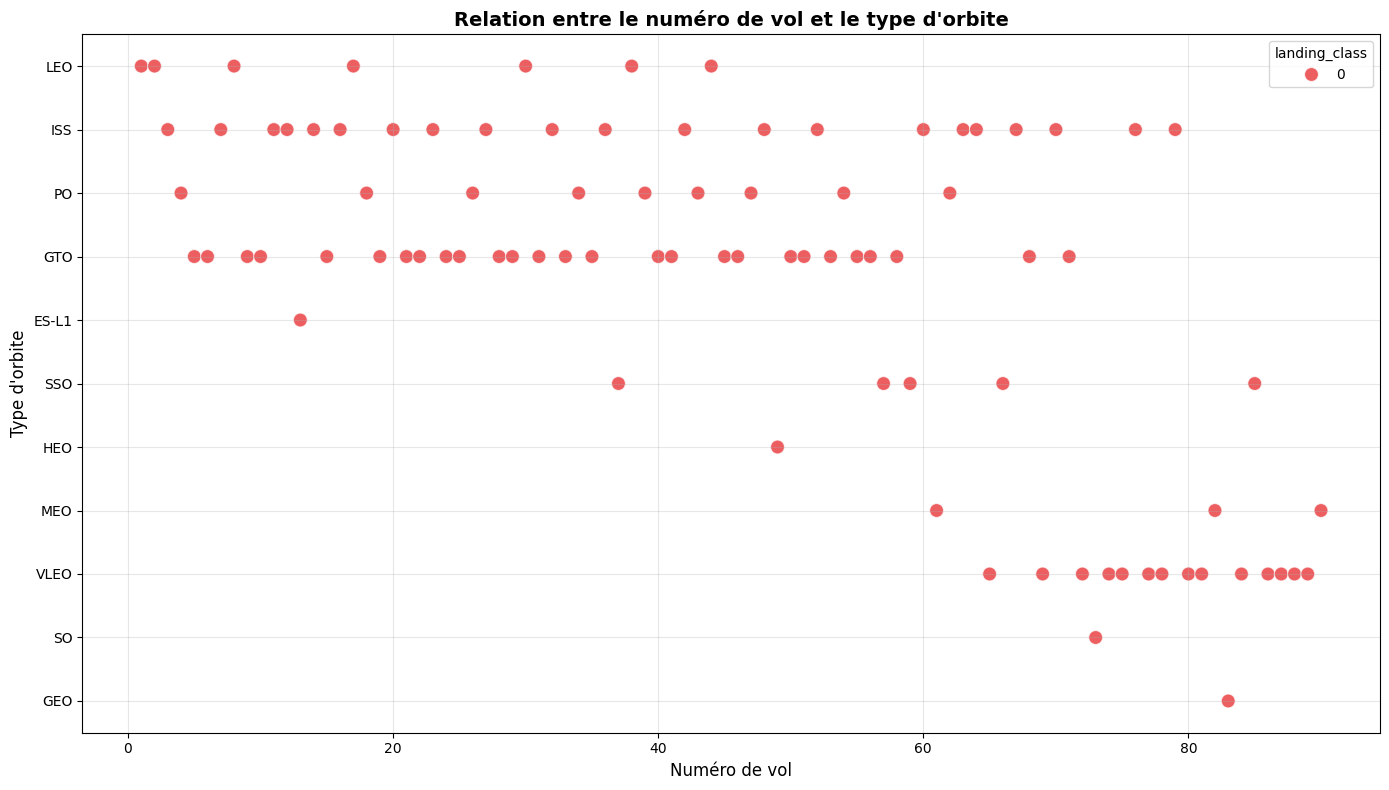

In [12]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
# Version la plus robuste
import seaborn as sns
import matplotlib.pyplot as plt

# Créer landing_class si nécessaire
if 'landing_class' not in df.columns:
    if 'Outcome' in df.columns:
        df['landing_class'] = df['Outcome'].apply(
            lambda x: 1 if 'Success' in str(x) else 0
        )
        print("✅ Colonne 'landing_class' créée avec succès")
    else:
        print("❌ Colonne 'Outcome' non trouvée")

# Créer le graphique
if 'landing_class' in df.columns:
    plt.figure(figsize=(14, 8))
    sns.scatterplot(
        x='FlightNumber',
        y='Orbit',
        data=df,
        hue='landing_class',
        palette='Set1',
        s=100,
        alpha=0.7
    )
    
    plt.title('Relation entre le numéro de vol et le type d\'orbite', fontsize=14, weight='bold')
    plt.xlabel('Numéro de vol', fontsize=12)
    plt.ylabel('Type d\'orbite', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.


### TASK  5: Visualize the relationship between Payload Mass and Orbit type


Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type


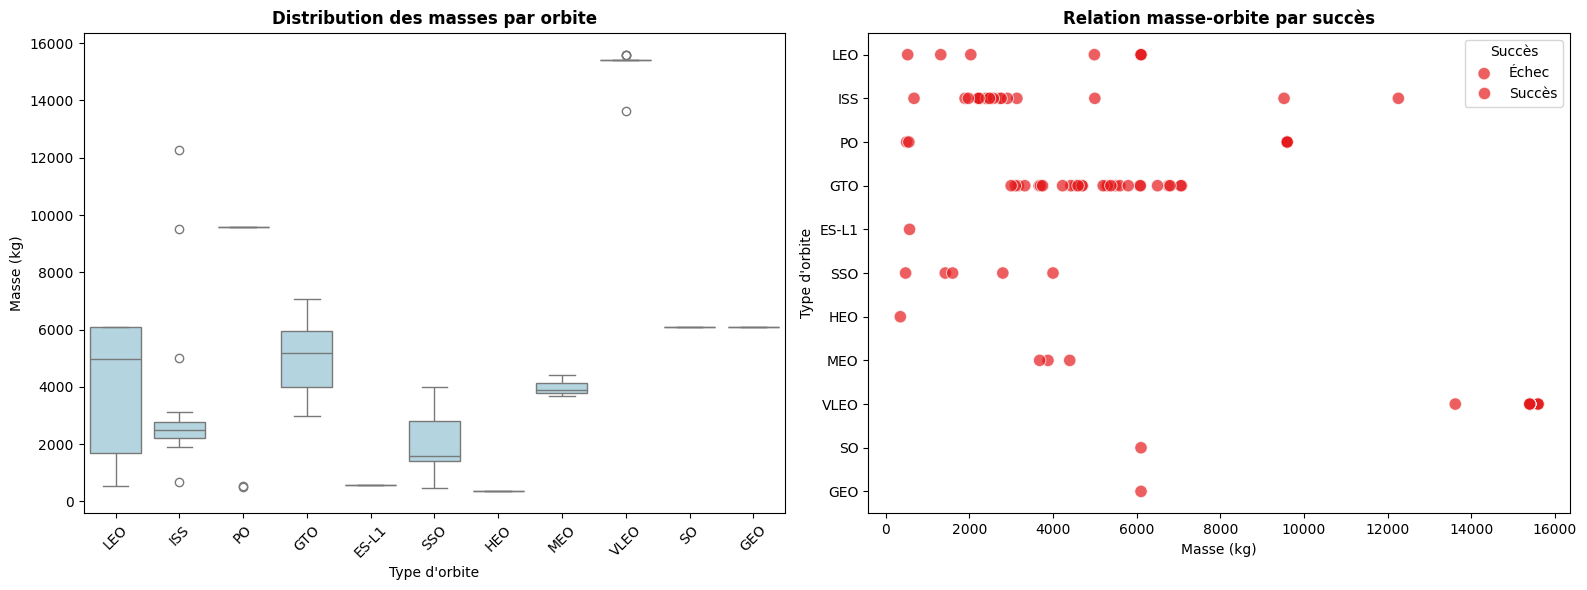

In [14]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value
import seaborn as sns
import matplotlib.pyplot as plt

# Créer landing_class si nécessaire
if 'landing_class' not in df.columns and 'Outcome' in df.columns:
    df['landing_class'] = df['Outcome'].apply(
        lambda x: 1 if 'Success' in str(x) else 0
    )

# Graphique combiné sans palette pour éviter l'avertissement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot - sans palette
sns.boxplot(
    x='Orbit',
    y='PayloadMass',
    data=df,
    color='lightblue',  # Utiliser une couleur unique
    ax=ax1
)
ax1.set_title('Distribution des masses par orbite', fontsize=12, weight='bold')
ax1.set_xlabel('Type d\'orbite')
ax1.set_ylabel('Masse (kg)')
ax1.tick_params(axis='x', rotation=45)

# 2. Scatter plot
sns.scatterplot(
    x='PayloadMass',
    y='Orbit',
    data=df,
    hue='landing_class',
    palette='Set1',
    s=80,
    alpha=0.7,
    ax=ax2
)
ax2.set_title('Relation masse-orbite par succès', fontsize=12, weight='bold')
ax2.set_xlabel('Masse (kg)')
ax2.set_ylabel('Type d\'orbite')
ax2.legend(title='Succès', labels=['Échec', 'Succès'])

plt.tight_layout()
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.


### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.


The function will help you get the year from the date:


In [15]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,landing_class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0,0


=== STATISTIQUES ANNUELLES DÉTAILLÉES ===
      success_rate  launch_count  success_count  failure_count  \
year                                                             
2010           0.0             1              0              1   
2012           0.0             1              0              1   
2013           0.0             3              0              3   
2014           0.0             6              0              6   
2015           0.0             6              0              6   
2016           0.0             8              0              8   
2017           0.0            18              0             18   
2018           0.0            18              0             18   
2019           0.0            10              0             10   
2020           0.0            19              0             19   

      cumulative_launches  cumulative_success  
year                                           
2010                    1                   0  
2012                 

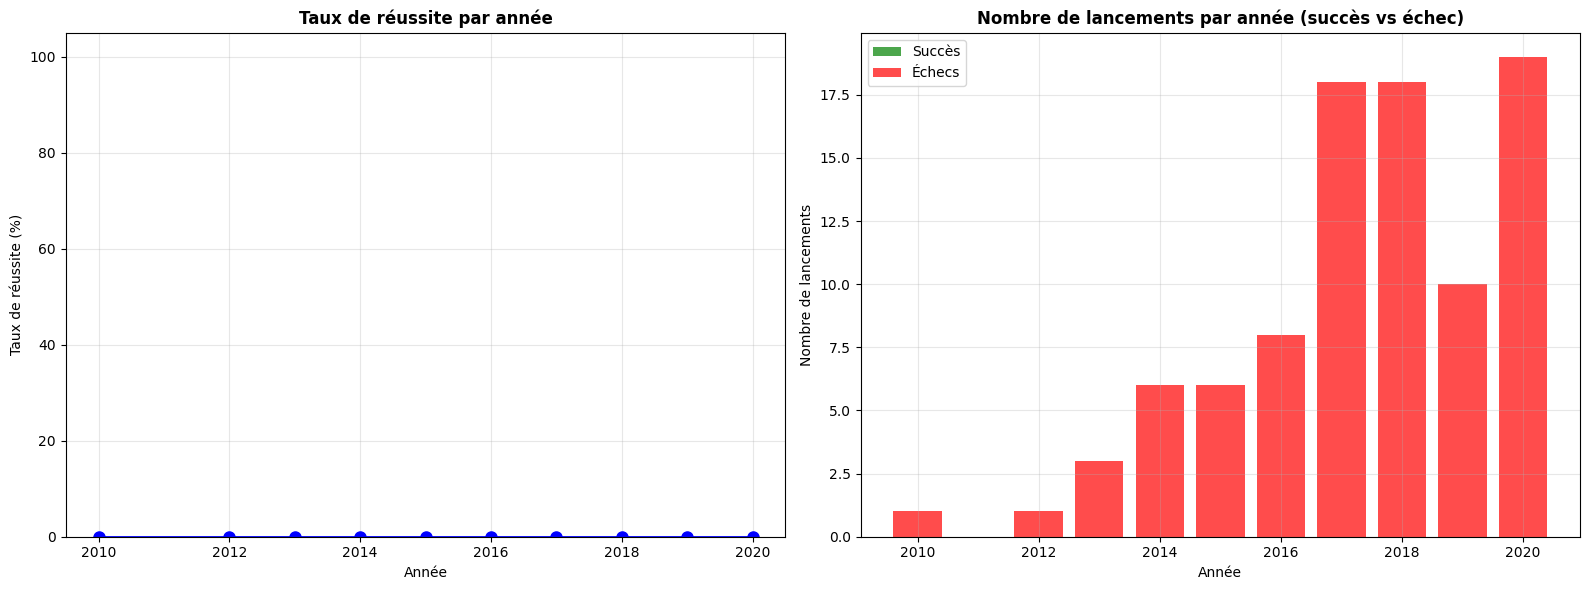

In [16]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
# Trouver les colonnes
date_col = None
outcome_col = None

for col in df.columns:
    if 'date' in col.lower():
        date_col = col
    if 'outcome' in col.lower():
        outcome_col = col

if outcome_col and 'landing_class' not in df.columns:
    df['landing_class'] = df[outcome_col].apply(
        lambda x: 1 if 'Success' in str(x) else 0
    )

if date_col and 'landing_class' in df.columns:
    # Extraire l'année
    df['year'] = pd.to_datetime(df[date_col]).dt.year
    
    # Statistiques annuelles
    yearly_stats = df.groupby('year').agg({
        'landing_class': ['mean', 'count', 'sum']
    }).round(2)
    yearly_stats.columns = ['success_rate', 'launch_count', 'success_count']
    yearly_stats['success_rate'] = yearly_stats['success_rate'] * 100
    yearly_stats['failure_count'] = yearly_stats['launch_count'] - yearly_stats['success_count']
    yearly_stats['cumulative_launches'] = yearly_stats['launch_count'].cumsum()
    yearly_stats['cumulative_success'] = yearly_stats['success_count'].cumsum()
    
    print("=== STATISTIQUES ANNUELLES DÉTAILLÉES ===")
    print(yearly_stats)
    
    # Créer le graphique
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Taux de réussite par année
    ax1.plot(yearly_stats.index, yearly_stats['success_rate'], 
             'o-', color='blue', linewidth=2, markersize=8)
    ax1.set_title('Taux de réussite par année', fontsize=12, weight='bold')
    ax1.set_xlabel('Année')
    ax1.set_ylabel('Taux de réussite (%)')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 105)
    
    # 2. Nombre de lancements par année (succès/échec)
    ax2.bar(yearly_stats.index, yearly_stats['success_count'], 
            color='green', alpha=0.7, label='Succès')
    ax2.bar(yearly_stats.index, yearly_stats['failure_count'], 
            bottom=yearly_stats['success_count'], color='red', alpha=0.7, label='Échecs')
    ax2.set_title('Nombre de lancements par année (succès vs échec)', fontsize=12, weight='bold')
    ax2.set_xlabel('Année')
    ax2.set_ylabel('Nombre de lancements')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ Colonnes nécessaires non trouvées")

you can observe that the sucess rate since 2013 kept increasing till 2020


## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [17]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [18]:
# HINT: Use get_dummies() function on the categorical columns

import pandas as pd

# Colonnes catégorielles à encoder
categorical_cols = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']

# Vérifier que les colonnes existent
existing_cols = [col for col in categorical_cols if col in df.columns]
missing_cols = [col for col in categorical_cols if col not in df.columns]

if missing_cols:
    print(f"⚠️ Colonnes manquantes: {missing_cols}")
    print("Colonnes disponibles:", df.columns.tolist())

# Créer les variables factices avec get_dummies
# drop_first=True évite la colinéarité (n-1 colonnes)
feature_one_hot = pd.get_dummies(df, columns=existing_cols, drop_first=True)

print("=== VARIABLES FACTICES CRÉÉES ===")
print(f"Shape original: {df.shape}")
print(f"Shape avec one-hot: {feature_one_hot.shape}")
print(f"Nombre de nouvelles colonnes: {feature_one_hot.shape[1] - df.shape[1]}")

print("\n=== APERÇU DES NOUVELLES COLONNES ===")
# Afficher les noms des colonnes qui ont été créées
for col in existing_cols:
    new_cols = [c for c in feature_one_hot.columns if c.startswith(col + '_')]
    if new_cols:
        print(f"{col}: {len(new_cols)} nouvelles colonnes")
        print(f"  Exemples: {new_cols[:3]}")

print("\n=== APERÇU DU DATAFRAME AVEC ONE-HOT ===")
print(feature_one_hot.head())

=== VARIABLES FACTICES CRÉÉES ===
Shape original: (90, 20)
Shape avec one-hot: (90, 84)
Nombre de nouvelles colonnes: 64

=== APERÇU DES NOUVELLES COLONNES ===
Orbit: 10 nouvelles colonnes
  Exemples: ['Orbit_GEO', 'Orbit_GTO', 'Orbit_HEO']
LaunchSite: 2 nouvelles colonnes
  Exemples: ['LaunchSite_KSC LC 39A', 'LaunchSite_VAFB SLC 4E']
LandingPad: 4 nouvelles colonnes
  Exemples: ['LandingPad_5e9e3032383ecb554034e7c9', 'LandingPad_5e9e3032383ecb6bb234e7ca', 'LandingPad_5e9e3032383ecb761634e7cb']
Serial: 52 nouvelles colonnes
  Exemples: ['Serial_B0005', 'Serial_B0007', 'Serial_B1003']

=== APERÇU DU DATAFRAME AVEC ONE-HOT ===
   FlightNumber  Date BoosterVersion  PayloadMass      Outcome  Flights  \
0             1  2010       Falcon 9  6104.959412    None None        1   
1             2  2012       Falcon 9   525.000000    None None        1   
2             3  2013       Falcon 9   677.000000    None None        1   
3             4  2013       Falcon 9   500.000000  False Ocean    

### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers, cast the entire dataframe to variable type <code>float64</code>


In [20]:
# HINT: use astype function
# Version la plus simple et robuste
# Identifier et convertir uniquement les colonnes numériques
numeric_cols = feature_one_hot.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns

if len(numeric_cols) > 0:
    feature_one_hot[numeric_cols] = feature_one_hot[numeric_cols].astype('float64')
    print(f"✅ {len(numeric_cols)} colonnes converties en float64")
else:
    print("❌ Aucune colonne numérique trouvée")

print(f"Shape: {feature_one_hot.shape}")
print("\n=== TYPES FINAUX ===")
print(feature_one_hot.dtypes.value_counts())

✅ 10 colonnes converties en float64
Shape: (90, 84)

=== TYPES FINAUX ===
bool       71
float64    10
object      3
Name: count, dtype: int64


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|
| 2024-07-18        | 1.2     | Anita Verma | Clarified instructions|
-->


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
